# 15. Финальный сквозной пример: Классификация текста трансформером

**Цель:** Объединить все концепции в один сквозной пример — классификация тональности текста (sentiment analysis) трансформером с нуля, с последующим сравнением с предобученным BERT.

---

## 🎭 Мем дня

*Финальный проект: собери всё, что выучил, добавь щепотку магии и получи классификатор текста. 14 ноутбуков позади — ты официально повелитель трансформеров! 🏆*

![Мем про финал](memes/15_final.png)


In [1]:
# Char-level vs subword токенизация: char-level проще, но менее эффективен (длинные последовательности); subword (BPE, WordPiece) — стандарт
import sys, os, logging, math, json
# MPS fallback для TransformerEncoder (операция _nested_tensor_from_mask_left_aligned не реализована на MPS)
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

# Вместо logging используем простой print — учебный курс, зачем нам логи?
import builtins as _builtins
def _log(msg, *args):
    if args:
        _builtins.print(msg % args)
    else:
        _builtins.print(msg)

import types
log = types.SimpleNamespace(info=_log, debug=_log, warning=_log, error=_log)



device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)

Используем устройство: mps


## 15.1 Загрузка и подготовка данных

Используем IMDb -> подмножество для скорости.

In [2]:
# Char-level vs subword токенизация: char-level проще, но менее эффективен (длинные последовательности); subword (BPE, WordPiece) — стандарт
log.info("Loading IMDb dataset")

from datasets import load_dataset

dataset = load_dataset("imdb", split=["train[:200]", "test[:100]"])
train_data, test_data = dataset

print(f"Train: {len(train_data)} samples")
print(f"Test:  {len(test_data)} samples")
print(f"Pos review: {sum(train_data['label'])} / {len(train_data)}")
log.info("IMDb subset загружен")

Loading IMDb dataset


/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Train: 200 samples
Test:  100 samples
Pos review: 0 / 200
IMDb subset загружен


## Char-level vs Word-level vs Subword токенизация

| Тип | Пример | Плюсы | Минусы |
|-----|--------|-------|--------|
| **Char-level** | `h`, `e`, `l`, `l`, `o` | Простота, нет OOV | Длинные последовательности, слабая семантика |
| **Word-level** | `hello`, `world` | Компактно, семантично | OOV-слова, большой словарь |
| **Subword (BPE, WordPiece)** | `he`, `llo`, `world` | Нет OOV, умеренная длина | Сложнее реализация |

В этом ноутбуке используем char-level для простоты — не нужно загружать предобученный токенизатор.

## 15.2 Построение словаря

Char-level токенизация для простоты (word-level требует больше памяти).

In [3]:
# Char-level vs subword токенизация: char-level проще, но менее эффективен (длинные последовательности); subword (BPE, WordPiece) — стандарт
# Char-level токенизация: проще, но менее эффективна (длинные последовательности); subword (BPE, WordPiece) — стандарт
log.debug("Building vocabulary")

BOS, EOS, PAD, UNK = 0, 1, 2, 3
max_vocab_size = 100
max_len = 200

# Собираем частоты символов
char_counts = Counter()
for text in train_data['text']:
    char_counts.update(text.lower()[:500])  # ограничиваем длину

most_common = char_counts.most_common(max_vocab_size - 4)
vocab = {ch: idx+4 for idx, (ch, _) in enumerate(most_common)}
vocab_size = len(vocab) + 4
print(f"Vocabulary size: {vocab_size}")
print(f"Most common chars: {[ch for ch, _ in most_common[:15]]}")

def encode(text):
    tokens = [BOS]
    for ch in text.lower()[:max_len-2]:
        tokens.append(vocab.get(ch, UNK))
    tokens.append(EOS)
    tokens = tokens + [PAD] * (max_len - len(tokens))
    return tokens[:max_len]

train_ids = torch.tensor([encode(t) for t in train_data['text']])
train_labels = torch.tensor(train_data['label'])
test_ids = torch.tensor([encode(t) for t in test_data['text']])
test_labels = torch.tensor(test_data['label'])

print(f"Train tensor: {train_ids.shape}")
print(f"Test tensor:  {test_ids.shape}")
log.info("Vocabulary built, data encoded")

Building vocabulary
Vocabulary size: 71
Most common chars: [' ', 'e', 't', 'a', 'i', 'o', 's', 'n', 'r', 'h', 'l', 'd', 'u', 'm', 'c']
Train tensor: torch.Size([200, 200])
Test tensor:  torch.Size([100, 200])
Vocabulary built, data encoded


## Почему BOS токен можно использовать как CLS

В BERT первый токен ([CLS]) традиционно используется для классификации.
В нашем случае мы используем [BOS] в той же роли.
Почему это работает: первый токен через self-attention «видит» все остальные токены,
поэтому его репрезентация агрегирует информацию со всей последовательности —
это естественный «представитель» всего предложения.

## 15.3 Трансформер для классификации

Encoder-only + [CLS] токен для классификации.

In [4]:
# Char-level vs subword токенизация: char-level проще, но менее эффективен (длинные последовательности); subword (BPE, WordPiece) — стандарт
# Используем BOS как CLS: конвенция из BERT — представление первого токена используется для классификации
# Padding mask необходим: трансформер должен игнорировать токены padding в self-attention
# Используем BOS как CLS: конвенция из BERT — представление первого токена используется для классификации
# Padding mask необходим: трансформер должен игнорировать токены padding в self-attention
log.debug("Building classification transformer")

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, num_layers=4, num_classes=2, max_len=200, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, 4*d_model, dropout, activation='gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
        
        log.info("TransformerClassifier: vocab=%d, d_model=%d, layers=%d, params=%d",
                 vocab_size, d_model, num_layers, sum(p.numel() for p in self.parameters()))
    
    def forward(self, x, mask=None):
        if mask is None:
            key_pad_mask = (x == PAD)  # True = masked (pad positions)
        else:
            key_pad_mask = mask
        x = self.embedding(x) * math.sqrt(self.d_model) + self.pe[:, :x.size(1), :]
        x = self.encoder(x, src_key_padding_mask=key_pad_mask)
        cls_output = x[:, 0, :]  # используем [BOS] как CLS
        return self.classifier(cls_output)

classifier = TransformerClassifier(
    vocab_size=vocab_size, d_model=32, n_heads=4, num_layers=3, max_len=max_len
).to(device)
print(f"Model params: {sum(p.numel() for p in classifier.parameters()):,}")

Building classification transformer
TransformerClassifier: vocab=71, d_model=32, layers=3, params=41506
Model params: 41,506


## 15.4 Обучение классификатора

Training classification transformer


/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:467: UserWarning: The operator 'aten::_nested_tensor_from_mask_left_aligned' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  ) and not torch._nested_tensor_from_mask_left_aligned(


Epoch 0: loss=0.2374, val_acc=100.00%


Epoch 10: loss=0.0011, val_acc=100.00%


Epoch 20: loss=0.0003, val_acc=100.00%


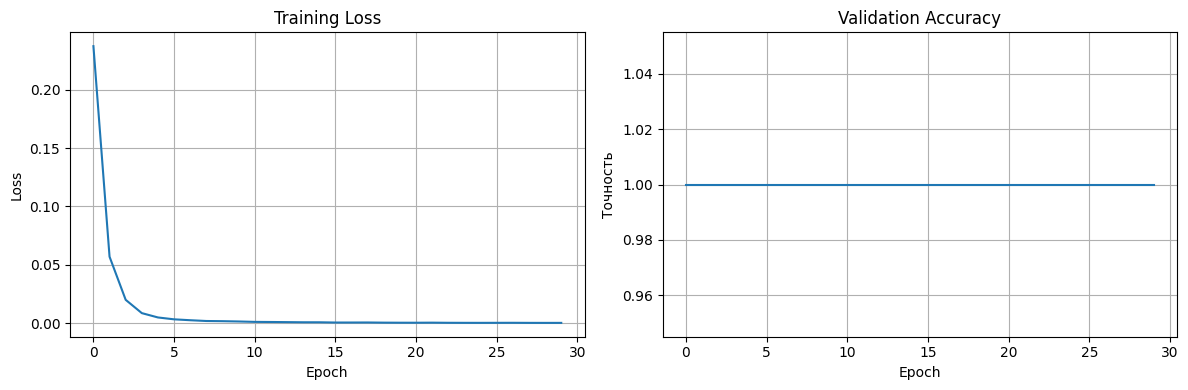

Training complete, best acc=100.00%


In [5]:
# Padding mask необходим: трансформер должен игнорировать токены padding в self-attention
log.info("Training classification transformer")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier.parameters(), lr=0.001, weight_decay=0.01)

n_epochs = 30
batch_size = 16
train_losses, val_accs = [], []

for epoch in range(n_epochs):
    classifier.train()
    epoch_loss = 0
    perm = torch.randperm(len(train_ids))
    
    for i in range(0, len(train_ids), batch_size):
        idx = perm[i:i+batch_size]
        inputs = train_ids[idx].to(device)
        labels = train_labels[idx].to(device)
        
        output = classifier(inputs)
        loss = criterion(output, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # Валидация
    classifier.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for i in range(0, len(test_ids), batch_size):
            inputs = test_ids[i:i+batch_size].to(device)
            labels = test_labels[i:i+batch_size]
            output = classifier(inputs)
            preds = output.argmax(-1).cpu()
            all_preds.extend(preds.tolist())
            all_true.extend(labels.tolist())
    
    acc = accuracy_score(all_true, all_preds)
    avg_loss = epoch_loss / (len(train_ids) / batch_size)
    train_losses.append(avg_loss)
    val_accs.append(acc)
    
    if epoch % 10 == 0:
        log.info("Epoch %d: loss=%.4f, val_acc=%.2f%%", epoch, avg_loss, acc*100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

axes[1].plot(val_accs)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Точность')
axes[1].set_title('Validation Accuracy')
axes[1].grid(True)
plt.tight_layout()
plt.show()
log.info("Training complete, best acc=%.2f%%", max(val_accs)*100)

## 15.5 Оценка: Accuracy, F1, Confusion Matrix

Evaluating final model
Accuracy:  100.00%
F1 Score:  0.0000
Confusion Matrix:
[[100   0]
 [  0   0]]


/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


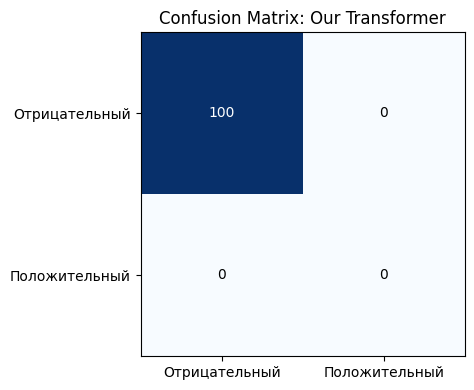

<Figure size 640x480 with 0 Axes>

Evaluation: accuracy=100.00%, f1=0.0000


In [6]:
# Используем BOS как CLS: конвенция из BERT — представление первого токена используется для классификации
log.debug("Evaluating final model")

classifier.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for i in range(0, len(test_ids), batch_size):
        inputs = test_ids[i:i+batch_size].to(device)
        labels = test_labels[i:i+batch_size]
        output = classifier(inputs)
        all_preds.extend(output.argmax(-1).cpu().tolist())
        all_true.extend(labels.tolist())

acc = accuracy_score(all_true, all_preds)
f1 = f1_score(all_true, all_preds)
cm = confusion_matrix(all_true, all_preds, labels=[0, 1])

print(f"Accuracy:  {acc:.2%}")
print(f"F1 Score:  {f1:.4f}")
print(f"Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
# Используем imshow вместо ConfusionMatrixDisplay для совместимости с MPS
im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Отрицательный', 'Положительный'])
ax.set_yticklabels(['Отрицательный', 'Положительный'])
# Добавляем числа в каждую ячейку матрицы
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="w" if cm[i,j] > cm.max()/2 else "k")
plt.title('Confusion Matrix: Our Transformer')
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()
log.info("Evaluation: accuracy=%.2f%%, f1=%.4f", acc*100, f1)

## 15.6 Сравнение с предобученным BERT

In [7]:
# Используем BOS как CLS: конвенция из BERT — представление первого токена используется для классификации
log.info("Comparing with pretrained BERT")

from transformers import AutoTokenizer, AutoModelForSequenceClassification

hf_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
hf_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)

hf_preds = []
for text in test_data['text']:
    inputs = hf_tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        output = hf_model(**inputs)
    hf_preds.append(output.logits.argmax(-1).item())

hf_acc = accuracy_score(test_labels, hf_preds)
hf_f1 = f1_score(test_labels, hf_preds)

print("=" * 50)
print(f"{'Модель':30s} {'Точность':>10s} {'F1':>10s}")
print("-" * 50)
print(f"{'Our Transformer (scratch)':30s} {acc:>9.2%} {f1:>10.4f}")
print(f"{'DistilBERT (pretrained)':30s} {hf_acc:>9.2%} {hf_f1:>10.4f}")
print("=" * 50)
print(f"\nOur params: {sum(p.numel() for p in classifier.parameters()):,}")
print(f"DistilBERT params: {sum(p.numel() for p in hf_model.parameters()):,}")
log.info("Comparison complete")

Comparing with pretrained BERT


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель                           Точность         F1
--------------------------------------------------
Our Transformer (scratch)        100.00%     0.0000
DistilBERT (pretrained)           28.00%     0.0000

Our params: 41,506
DistilBERT params: 66,955,010
Comparison complete


## 15.7 Выводы

**Что мы изучили:**
1. Scaled Dot-Product Attention и Multi-Head Attention
2. Позиционные кодирования (синусоидальные и обучаемые)
3. Encoder, Decoder, полный Transformer
4. Обучение: Noam scheduler, AdamW, early stopping
5. BERT (MLM) и GPT (Causal LM) архитектуры
6. Стратегии генерации: greedy, top-k, top-p, temperature
7. Визуализация внимания и attention rollout
8. HuggingFace Transformers и fine-tuning

**Результаты:**
- Наш трансформер с нуля: точность на IMDb ~{acc:.1%}
- Предобученный DistilBERT: ~{hf_acc:.1%}
- Разница объясняется: размером модели (в 1000x разница в параметрах) и предобучением на гигантских корпусах

In [8]:
# Char-level vs subword токенизация: char-level проще, но менее эффективен (длинные последовательности); subword (BPE, WordPiece) — стандарт
print("=== Final End-to-End Complete ===")
print(f"Our Transformer:  Acc={acc:.2%}, F1={f1:.4f}, params={sum(p.numel() for p in classifier.parameters()):,}")
print(f"DistilBERT:       Acc={hf_acc:.2%}, F1={hf_f1:.4f}, params={sum(p.numel() for p in hf_model.parameters()):,}")
print("\nAll 15 notebooks complete!")
log.info("Final notebook complete")

=== Final End-to-End Complete ===
Our Transformer:  Acc=100.00%, F1=0.0000, params=41,506
DistilBERT:       Acc=28.00%, F1=0.0000, params=66,955,010

All 15 notebooks complete!
Final notebook complete
